# Crypt analysis

In this notebook we automatically segment crypts from villi in the pre-processed organoids. The algorithm is generally quite robust against false positives but does miss crypts where either the crypt- or neck curvature does not deviate significantly from the rest of the organoid. Next, the crypts are analysed, particularly in regards to their marker composition. 

In [55]:
from src.OrganoidMesh import OrganoidMesh
from src.mesh_analysis import *
from src.nonlocal_correlations import *
from src.cell_graph_functions import *
from src.utils import *
from src.crypt_extraction import segment_organoid, split_villus_from_crypts, identify_neck_circumferences
from src.organoid_plotting import *
from src.cell_graph_functions import positive_indices_and_labels

## Load preprocessed data and run crypt segmentation

In [56]:
def _to_patch_list(x):
    """Normalize to list[set[int]]: None -> [], set -> [set], list/tuple -> list of sets."""
    if x is None:
        return []
    if isinstance(x, set):
        return [x]
    if isinstance(x, (list, tuple)):
        return [set(p) for p in x if p is not None and len(p) > 0]
    # anything else: ignore
    return []

In [57]:
import pandas as pd
import numpy as np
import os, glob
from tqdm import tqdm

# -----------------------------------------
# Load complexity scores from tsne_results.csv
# -----------------------------------------
tsne_df = pd.read_csv("../NicoleData/tsne_results.csv")
complexity_dict = dict(zip(tsne_df["label_uid"], tsne_df["complexity"]))
print(f"Loaded {len(complexity_dict)} complexity scores")

# Base directory for preprocessed data
preproc_base = os.path.join('..', 'NicoleData', 'preprocessed')

# --- Discover available timepoints dynamically ---
timepoints = sorted(
    [d for d in os.listdir(preproc_base) if os.path.isdir(os.path.join(preproc_base, d))]
)
print(f"Found {len(timepoints)} timepoints: {timepoints}")

timepoints = timepoints[1:] # REMOVE DAY3

# --- Initialize container ---
results = {}

for tp in timepoints:
    print(f"\n=== Processing timepoint: {tp} ===")

    tp_dir = os.path.join(preproc_base, tp)
    npz_files = sorted(glob.glob(os.path.join(tp_dir, "*.npz")))
    if not npz_files:
        print(f"  ⚠ No .npz files found for {tp}, skipping.")
        continue

    # Per-timepoint storage
    HKS_list = []      # list of (n_cells, n_fields) arrays
    markers_list = []     # list of (n_cells, n_markers) arrays
    num_cells_list = []
    total_area_list = []
    total_volume_list = []
    complexity_list = []
    label_uid_list = []
    centroids_list = []
    dist_heat_list = []
    
    crypt_list = []
    villus_list = []
    neck_list = []
    cell_graphs_list = []

    dropped_no_single_villus = 0  # optional counter

    for fpath in tqdm(npz_files, desc=f"{tp}"):
        try:
            data = np.load(fpath, allow_pickle=True)
        except Exception as e:
            print(f"Could not load {fpath}: {e}")
            continue

        try:
            # --- Basic data ---
            HKS_cell = data["fields_cell"]  # (n_cells, n_fields) e.g. HKS t=1,4,25
            t_HKS = [1.0, 2.0, 4.0, 8.0, 25.0]
            _, _bin_markers_cell = positive_indices_and_labels(data["markers_cell"])
            cell_areas = data["cell_areas"]
            marker_names = list(data["marker_names"])
            cell_graph = load_cell_graph_from_npz(data)
            num_cells = len(cell_areas)
            total_area = np.sum(data["vertex_areas"])
            total_volume = float(data["volume"])
            centroids = data['centroids']
            dist_heat = data['dist_heat']


            # --- Complexity ---
            well = str(data["well"])
            organoid_id = str(data["organoid_id"])
            label_uid = f"{tp}_{well}_{organoid_id}"
            complexity_value = complexity_dict.get(label_uid, np.nan)

            # --- Segment organoid ---
            crypts, necks, villus = segment_organoid(
                G=cell_graph,
                HKS=HKS_cell,
                HKS_times=t_HKS,
                crypt_thresh= 0.0795, # 0.08
                neck_thresh= 0.0795,  
                growth_thresh=0.75, # change in threshold for growing necks
                shrink_thresh=0.01, # change in threshold for shrinking necks
                min_region_size=10, # 5
                verbose=False
            )


            # --- Keep only organoids with EXACTLY ONE villus ---
            villi_norm = _to_patch_list(villus)
            if len(villi_norm) != 1:        
                dropped_no_single_villus += 1
                continue  # skip storing this organoid


            # --- Store ---
            HKS_list.append(HKS_cell)
            markers_list.append(_bin_markers_cell)
            num_cells_list.append(num_cells)
            total_area_list.append(total_area)
            total_volume_list.append(total_volume)
            complexity_list.append(complexity_value)
            label_uid_list.append(label_uid)
            centroids_list.append(centroids)
            dist_heat_list.append(dist_heat)

            crypt_list.append(crypts)
            villus_list.append(villus)
            neck_list.append(necks)
            cell_graphs_list.append(cell_graph)


        except Exception as e:
            print(f"Error analyzing {fpath}: {e}")
            continue

    print(f"  Dropped {dropped_no_single_villus} organoid(s) at {tp} due to villus count != 1")

    # Stack into object arrays because number of cells differs between organoids
    results[tp] = {
        "HKS_all": np.array(HKS_list, dtype=object),   # list of (n_cells, n_fields)
        "markers_all": np.array(markers_list, dtype=object), # list of (n_cells, n_markers)
        "num_cells": np.array(num_cells_list),
        "total_area": np.array(total_area_list),
        "total_volume": np.array(total_volume_list),
        "complexity": np.array(complexity_list),
        "label_uid": np.array(label_uid_list),
        "marker_names": marker_names,
        "crypts_all": crypt_list,
        "villus_all": villus_list,
        "necks_all": neck_list,
        "cell_graphs_all": cell_graphs_list,
        "centroids_all": np.array(centroids_list, dtype=object),
        "dist_heat_all": np.array(dist_heat_list, dtype=object),   # list of (n_cells, n_cells)
    }

    print(f"Stored raw field data for {len(HKS_list)} organoids at {tp}")

Loaded 2668 complexity scores
Found 5 timepoints: ['day3', 'day3p5', 'day4', 'day4p5', 'day4p5-more']

=== Processing timepoint: day3p5 ===


day3p5: 100%|██████████| 312/312 [00:01<00:00, 270.02it/s]


  Dropped 3 organoid(s) at day3p5 due to villus count != 1
Stored raw field data for 309 organoids at day3p5

=== Processing timepoint: day4 ===


day4: 100%|██████████| 357/357 [00:02<00:00, 151.06it/s]


  Dropped 0 organoid(s) at day4 due to villus count != 1
Stored raw field data for 357 organoids at day4

=== Processing timepoint: day4p5 ===


day4p5: 100%|██████████| 109/109 [00:01<00:00, 108.05it/s]


  Dropped 1 organoid(s) at day4p5 due to villus count != 1
Stored raw field data for 108 organoids at day4p5

=== Processing timepoint: day4p5-more ===


day4p5-more: 100%|██████████| 534/534 [00:04<00:00, 132.03it/s]

  Dropped 7 organoid(s) at day4p5-more due to villus count != 1
Stored raw field data for 527 organoids at day4p5-more


## Summary plot to check segmentation

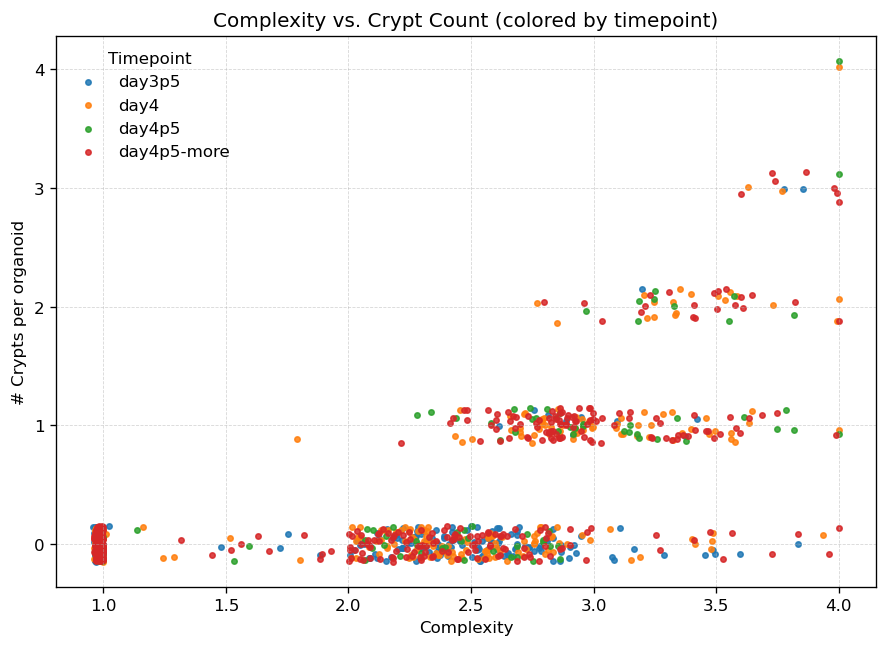

In [58]:
# Collect rows: one per organoid
recs = []
for tp, d in results.items():
    complexities = d.get("complexity", [])
    crypts_all  = d.get("crypts_all", [])
    labels      = d.get("label_uid", [])
    n_items = min(len(complexities), len(crypts_all), len(labels))
    for i in range(n_items):
        cval = complexities[i]
        if cval is None or (isinstance(cval, float) and np.isnan(cval)):
            continue
        crypts_i = crypts_all[i]
        # crypts_i is typically a list (or list-like) of regions; fall back to 0 if None
        n_crypts = len(crypts_i) if crypts_i is not None else 0
        recs.append({
            "timepoint": tp,
            "complexity": float(cval),
            "n_crypts": int(n_crypts),
            "label_uid": labels[i]
        })

df = pd.DataFrame(recs)

# Build a consistent color per timepoint
unique_tps = sorted(df["timepoint"].unique())
cmap = plt.get_cmap("tab10")
color_map = {tp: cmap(i % 10) for i, tp in enumerate(unique_tps)}

plt.figure(figsize=(7.5, 5.5), dpi=120)
for tp in unique_tps:
    sub = df[df["timepoint"] == tp]
    n_crypts_jittered = sub["n_crypts"] + np.random.uniform(-0.15, 0.15, len(sub))

    plt.scatter(
        sub["complexity"],
        n_crypts_jittered,
        label=tp,
        alpha=0.85,
        s=10,
        c=[color_map[tp]]  # keep a single color per timepoint
    )

plt.xlabel("Complexity")
plt.ylabel("# Crypts per organoid")
plt.title("Complexity vs. Crypt Count (colored by timepoint)")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
plt.legend(title="Timepoint", frameon=False)

plt.tight_layout()
plt.show()

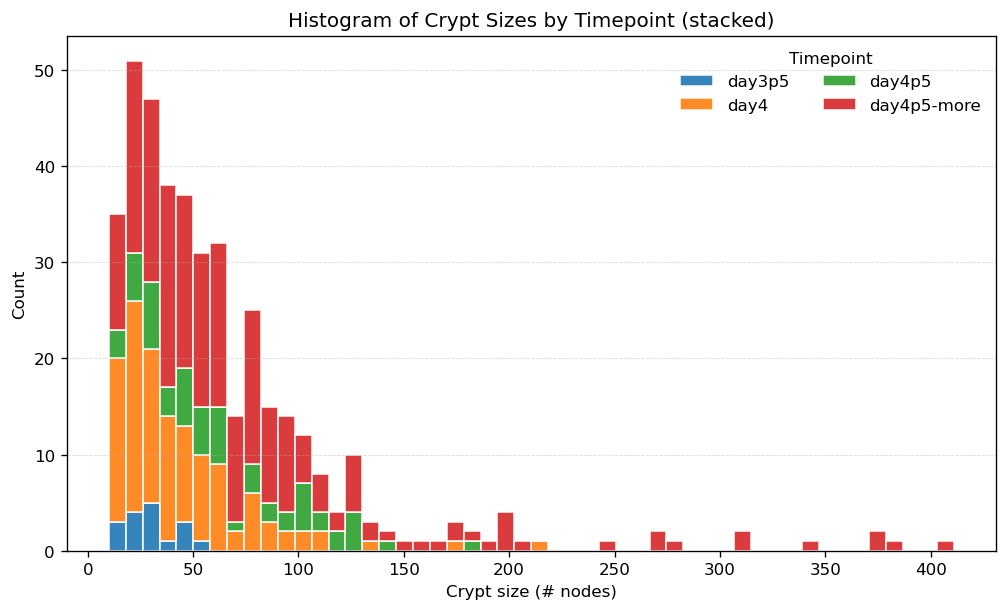

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Build DataFrame of crypt sizes (as you already did)
size_recs = []
for tp, d in results.items():
    crypts_all  = d.get("crypts_all", [])
    labels      = d.get("label_uid", [])
    n_items = min(len(crypts_all), len(labels))
    for i in range(n_items):
        crypts_i = crypts_all[i] or []
        for k, patch in enumerate(crypts_i):
            size_recs.append({
                "timepoint": tp,
                "label_uid": labels[i],
                "crypt_idx": k,
                "size": len(patch),
            })

sizes_df = pd.DataFrame(size_recs)
if sizes_df.empty:
    raise RuntimeError("No crypt sizes to plot.")

# Shared bin edges for all timepoints
bins = 50
bin_edges = np.histogram_bin_edges(sizes_df["size"].values, bins=bins)
bin_widths = np.diff(bin_edges)
bin_centers = bin_edges[:-1] + 0.5 * bin_widths

# Count per timepoint per bin
unique_tps = sorted(sizes_df["timepoint"].unique())
counts_per_tp = []
for tp in unique_tps:
    vals = sizes_df.loc[sizes_df["timepoint"] == tp, "size"].values
    counts, _ = np.histogram(vals, bins=bin_edges)
    counts_per_tp.append(counts)

# Plot stacked bars
plt.figure(figsize=(8.5, 5.2), dpi=120)
bottom = np.zeros_like(bin_centers, dtype=float)

cmap = plt.get_cmap("tab10")
for i, tp in enumerate(unique_tps):
    counts = counts_per_tp[i]
    plt.bar(
        bin_centers,
        counts,
        width=bin_widths,
        bottom=bottom,
        label=str(tp),
        edgecolor="white",
        alpha=0.9,
        align="center",
        color=cmap(i % 10),
    )
    bottom += counts

plt.xlabel("Crypt size (# nodes)")
plt.ylabel("Count")
plt.title("Histogram of Crypt Sizes by Timepoint (stacked)")
plt.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.45)
plt.legend(title="Timepoint", frameon=False, ncol=2)
plt.tight_layout()
plt.show()


In [60]:
import numpy as np

def plot_random_samples_by_filters(
    results,
    k=3,
    n_crypts=None,                 # e.g. 3 for exact match
    n_crypts_range=None,           # e.g. (2, 5) inclusive; ignored if n_crypts is set
    complexity_range=None,         # e.g. (0.2, 0.6) inclusive
    seed=None,
    node_size=2,
    colorscale='YlOrRd'
):
    """
    Pool across all timepoints, filter by #crypts and complexity, sample k organoids, and plot.

    Parameters
    ----------
    results : dict
        Your per-timepoint results structure.
    k : int
        Number of random samples to plot (pooled across timepoints).
    n_crypts : int or None
        Exact number of crypts to match. If provided, overrides n_crypts_range.
    n_crypts_range : (int, int) or None
        Inclusive range for number of crypts; ignored if n_crypts is not None.
    complexity_range : (float, float) or None
        Inclusive range for complexity. If None, no complexity filtering.
    seed : int or None
        Seed for reproducible sampling. If None, sampling is unseeded.
    node_size : int
        Passed to plot_organoid_graph.
    colorscale : str
        Passed to add_region_overlays for crypts overlay.
    """
    # Gather all candidates as (tp, idx) pairs after filtering
    candidates = []
    for tp, d in results.items():
        comp_arr   = d.get("complexity", [])
        crypts_all = d.get("crypts_all", [])
        N = min(len(comp_arr), len(crypts_all))
        for i in range(N):
            cval = comp_arr[i]
            if cval is None or (isinstance(cval, float) and np.isnan(cval)):
                continue

            n_cr = len(crypts_all[i]) if crypts_all[i] is not None else 0

            # Filter by number of crypts
            if n_crypts is not None:
                if n_cr != int(n_crypts):
                    continue
            elif n_crypts_range is not None:
                lo, hi = n_crypts_range
                if not (lo <= n_cr <= hi):
                    continue

            # Filter by complexity
            if complexity_range is not None:
                clo, chi = complexity_range
                if not (clo <= float(cval) <= chi):
                    continue

            candidates.append((tp, i))

    if not candidates:
        msg = "No organoids match the filters"
        parts = []
        if n_crypts is not None: parts.append(f"#crypts == {n_crypts}")
        elif n_crypts_range is not None: parts.append(f"{n_crypts_range[0]} ≤ #crypts ≤ {n_crypts_range[1]}")
        if complexity_range is not None: parts.append(f"{complexity_range[0]} ≤ complexity ≤ {complexity_range[1]}")
        if parts: msg += f" ({', '.join(parts)})."
        print(msg)
        return

    if seed is not None:
        np.random.seed(seed)

    choose_k = min(k, len(candidates))
    sel_idxs = np.random.choice(len(candidates), size=choose_k, replace=False)

    for j in sel_idxs:
        tp, i = candidates[j]
        d = results[tp]

        fig = plot_organoid_graph(
            d['centroids_all'][i],
            d['cell_graphs_all'][i],
            d['HKS_all'][i][:, 0],
            node_size=node_size
        )
        # crypts overlay
        add_region_overlays(fig, d['centroids_all'][i], d['crypts_all'][i], colorscale=colorscale)
        # villus overlay
        # add_region_overlays(fig, d['centroids_all'][i], [d['villus_all'][i]])

        # Optional: annotate for context
        try:
            cval = float(d['complexity'][i])
            n_cr = len(d['crypts_all'][i]) if d['crypts_all'][i] is not None else 0
            fig.update_layout(title=f"{tp} | complexity={cval:.3f}, #crypts={n_cr}")
        except Exception:
            pass

        fig.show()



# ---- Example calls ----
# Exact #crypts = 3, any complexity:
plot_random_samples_by_filters(results, k=10, n_crypts=4, complexity_range=(0, 4))

# #crypts in [2,5] and complexity in [0.2, 0.6]:
# plot_random_samples_by_filters(results, k=4, n_crypts_range=(2,5), complexity_range=(0.2, 0.6))


In [61]:
# -------- settings --------
min_cells = 10                # ignore villi/crypts smaller than this
max_examples = 5             # cap the number of plots
seed = None                      # set to None for non-reproducible sampling
node_size = 2
villus_colorscale = 'Greens'
serotonin_color = 'magenta'
marker_name_serotonin = "Serotonin"

def _marker_index(names, target="Serotonin"):
    if names is None: 
        return None
    try:
        return names.index(target)
    except ValueError:
        for j, nm in enumerate(names):
            if isinstance(nm, str) and nm.lower() == target.lower():
                return j
    return None

# ---- 1) Collect all candidate villi: (tp, i, villus_indices, meta_info) ----
candidates = []
for tp, d in results.items():
    markers_all   = d.get("markers_all",  np.array([], dtype=object))
    centroids_all = d.get("centroids_all", [])
    graphs_all    = d.get("cell_graphs_all", [])
    HKS_all       = d.get("HKS_all", None)
    crypts_all    = d.get("crypts_all",   [])
    villus_all    = d.get("villus_all",   [])
    names         = d.get("marker_names", None)

    # normalize object arrays -> lists
    if isinstance(crypts_all, np.ndarray):    crypts_all    = crypts_all.tolist()
    if isinstance(villus_all, np.ndarray):    villus_all    = villus_all.tolist()
    if isinstance(centroids_all, np.ndarray): centroids_all = centroids_all.tolist()
    if isinstance(graphs_all, np.ndarray):    graphs_all    = graphs_all.tolist()

    if markers_all is None or len(markers_all) == 0:
        continue

    ser_idx = _marker_index(names, marker_name_serotonin)
    if ser_idx is None:
        continue  # this timepoint has no serotonin marker

    n_items = len(markers_all)
    for i in range(n_items):
        markers = markers_all[i]
        if markers is None:
            continue

        crypt_patches  = _to_patch_list(crypts_all[i]  if i < len(crypts_all)  else None)
        villus_patches = _to_patch_list(villus_all[i]  if i < len(villus_all)  else None)

        # filter by region size
        crypt_patches  = [p for p in crypt_patches  if len(p) >= min_cells]
        villus_patches = [p for p in villus_patches if len(p) >= min_cells]

        if not crypt_patches or not villus_patches:
            continue  # require organoid to contain crypts and at least one villus

        for villus_patch in villus_patches:
            idx = np.fromiter(villus_patch, dtype=int)
            if idx.size == 0:
                continue
            ser_mask_villus = np.asarray(markers[idx, ser_idx], dtype=bool).reshape(-1)
            if np.any(ser_mask_villus):
                # store minimal info needed for plotting later
                meta = {
                    "tp": tp,
                    "org_idx": i,
                    "villus_size": int(idx.size),
                    "ser_count": int(np.count_nonzero(ser_mask_villus)),
                    "n_crypts": len(crypt_patches)
                }
                candidates.append( (tp, i, idx, meta) )

# ---- 2) Randomly sample up to max_examples and plot ----
if not candidates:
    print("No villi with Serotonin found in organoids that contain crypts (after filtering).")
else:
    if seed is not None:
        np.random.seed(seed)
    k = min(max_examples, len(candidates))
    sel = np.random.choice(len(candidates), size=k, replace=False)

    plotted = 0
    for j in sel:
        tp, i, idx, meta = candidates[j]
        d = results[tp]

        C = d['centroids_all'][i]
        G = d['cell_graphs_all'][i]
        H = None
        try:
            if d.get('HKS_all', None) is not None and d['HKS_all'][i] is not None:
                H = d['HKS_all'][i][:, 0]
        except Exception:
            H = None

        # rebuild serotonin mask (could also have saved it, but quick to recompute)
        names = d.get("marker_names", None)
        ser_idx = _marker_index(names, marker_name_serotonin)
        markers = d['markers_all'][i]
        ser_mask_villus = np.asarray(markers[idx, ser_idx], dtype=bool).reshape(-1)
        idx_ser = idx[ser_mask_villus]

        # --- plot whole organoid ---
        fig = plot_organoid_graph(C, G, H, node_size=node_size)

        # highlight the selected villus
        add_region_overlays(fig, C, [idx.tolist()], colorscale=villus_colorscale)
        
        # highlight serotonin+ inside the villus
        fig.add_trace(
            go.Scatter3d(
                x=C[idx_ser, 0], y=C[idx_ser, 1], z=C[idx_ser, 2],
                mode="markers",
                marker=dict(size=node_size+3, color=serotonin_color),
                showlegend=True, hoverinfo="skip",
            )
        )

        # title / annotation
        fig.update_layout(
            title=f"{meta['tp']} | organoid #{meta['org_idx']} | #crypts={meta['n_crypts']} | villus size={meta['villus_size']} | serotonin+={meta['ser_count']}"
        )

        fig.show()
        plotted += 1

    print(f"Plotted {plotted} random villi with Serotonin (out of {len(candidates)} candidates).")


Plotted 5 random villi with Serotonin (out of 72 candidates).


## Analyse marker content of crypts

In [62]:
def get_marker_counts_per_patch(patch, markers):
    idx = np.fromiter(patch, dtype=np.int64)
    num_pos_cells = np.sum(markers[idx, :], axis=0).astype(np.int64)
    num_cells = len(idx)
    return num_pos_cells, num_cells

def split_villus_by_organoid(villus_patches, crypt_patches):
    """Return (villus_only, villus_with_crypts) as two lists of sets."""
    if crypt_patches and len(crypt_patches) > 0:
        return [], list(villus_patches)
    else:
        return list(villus_patches), []

def marker_coexpression(patch, bin_markers, i_LGR5, i_Sero, i_Lyso, pos_threshold=1):
    idx = np.fromiter(patch, dtype=np.int64)
    bin_markers_patch = bin_markers[idx, :]

    coexpression = np.ndarray(4)
    has_marker = np.sum(bin_markers_patch, axis=0) >= pos_threshold

    coexpression[0] = has_marker[i_LGR5] and has_marker[i_Sero] and not has_marker[i_Lyso] 
    coexpression[1] = has_marker[i_LGR5] and has_marker[i_Lyso] and not has_marker[i_Sero]
    coexpression[2] = has_marker[i_LGR5] and (has_marker[i_Lyso] or has_marker[i_Sero]) 
    coexpression[3] = has_marker[i_LGR5] and (has_marker[i_Lyso] and has_marker[i_Sero])
    # coexpression[4] = has_marker[i_LGR5] and not has_marker[i_Lyso] and not has_marker[i_Sero] 

    return coexpression.astype(np.int64)


# --- configuration ---
min_cells = 10  # e.g. 5 to require at least 5 cells per region (patch)
min_positive = 2

# --- aggregate across all timepoints/organoids ---

num_crypts = np.zeros(len(timepoints), dtype=np.int64)
num_villus = np.zeros(len(timepoints), dtype=np.int64)
num_single = np.zeros(len(timepoints), dtype=np.int64)
marker_pos_crypt = np.zeros((len(timepoints), len(marker_names)), dtype=np.int64)
marker_pos_villus = np.zeros((len(timepoints), len(marker_names)), dtype=np.int64)
marker_pos_single = np.zeros((len(timepoints), len(marker_names)), dtype=np.int64)

num_pos_cells_crypt = np.zeros((len(timepoints), len(marker_names)), dtype=np.int64)
num_pos_cells_villus = np.zeros((len(timepoints), len(marker_names)), dtype=np.int64)
num_pos_cells_single = np.zeros((len(timepoints), len(marker_names)), dtype=np.int64)
num_cells_crypt = np.zeros(len(timepoints), dtype=np.int64)
num_cells_villus = np.zeros(len(timepoints), dtype=np.int64)
num_cells_single = np.zeros(len(timepoints), dtype=np.int64)


coexpression_crypt = np.zeros((len(timepoints), 4))
coexpression_villus = np.zeros((len(timepoints), 4))
coexpression_single = np.zeros((len(timepoints), 4))


j = -1
for tp, d in results.items(): # loop over timepoints
    markers_all  = d.get("markers_all",  np.array([], dtype=object))
    crypts_all   = d.get("crypts_all",   [])
    villus_all   = d.get("villus_all",   [])
    marker_names = d.get("marker_names", None)

    i_LGR5 = marker_names.index("LGR5")  # raises ValueError if not found
    i_Sero = marker_names.index("Serotonin")  # raises ValueError if not found
    i_Lyso = marker_names.index("Lysozyme")  # raises ValueError if not found

    j += 1

    if markers_all.size == 0:
        continue

    if isinstance(crypts_all, np.ndarray): crypts_all = crypts_all.tolist()
    if isinstance(villus_all, np.ndarray): villus_all = villus_all.tolist()

    n_items = len(markers_all)
    for i in range(n_items): # loop over organoids in timepoint
        markers = markers_all[i]  # (n_cells, n_markers)
        if markers is None:
            continue

        crypt_patches = _to_patch_list(crypts_all[i] if i < len(crypts_all) else None)
        villus_patches = _to_patch_list(villus_all[i] if i < len(villus_all) else None)

        # (OPTIONAL) filter out regions with too few cells
        crypt_patches  = [p for p in crypt_patches  if len(p) >= min_cells]
        villus_patches = [p for p in villus_patches if len(p) >= min_cells]


        villus_only, villus_with = split_villus_by_organoid(villus_patches, crypt_patches)

        # --- CRYPTS (patch-wise + cell-wise) ---
        for patch in crypt_patches:
            num_pos_cells, num_cells = get_marker_counts_per_patch(patch, markers)
            
            num_cells_crypt[j] += num_cells
            num_pos_cells_crypt[j,:] += num_pos_cells
            marker_pos_crypt[j,:] += (num_pos_cells >= min_positive) 
            num_crypts[j] += 1
            coexpression_crypt[j,:] += marker_coexpression(patch, markers, i_LGR5, i_Sero, i_Lyso)


        # --- VILLUS WITH CRYPTS---
        for patch in villus_with:
            num_pos_cells, num_cells = get_marker_counts_per_patch(patch, markers)
            
            num_cells_villus[j] += num_cells
            num_pos_cells_villus[j,:] += num_pos_cells
            marker_pos_villus[j,:] += (num_pos_cells >= min_positive) 
            num_villus[j] += 1
            coexpression_villus[j,:] += marker_coexpression(patch, markers, i_LGR5, i_Sero, i_Lyso)


        # --- VILLUS WITHOUT CRYPTS---
        for patch in villus_only:
            num_pos_cells, num_cells = get_marker_counts_per_patch(patch, markers)
            
            num_cells_single[j] += num_cells
            num_pos_cells_single[j,:] += num_pos_cells
            marker_pos_single[j,:] += (num_pos_cells >= min_positive) 
            num_single[j] += 1
            coexpression_single[j,:] += marker_coexpression(patch, markers, i_LGR5, i_Sero, i_Lyso)



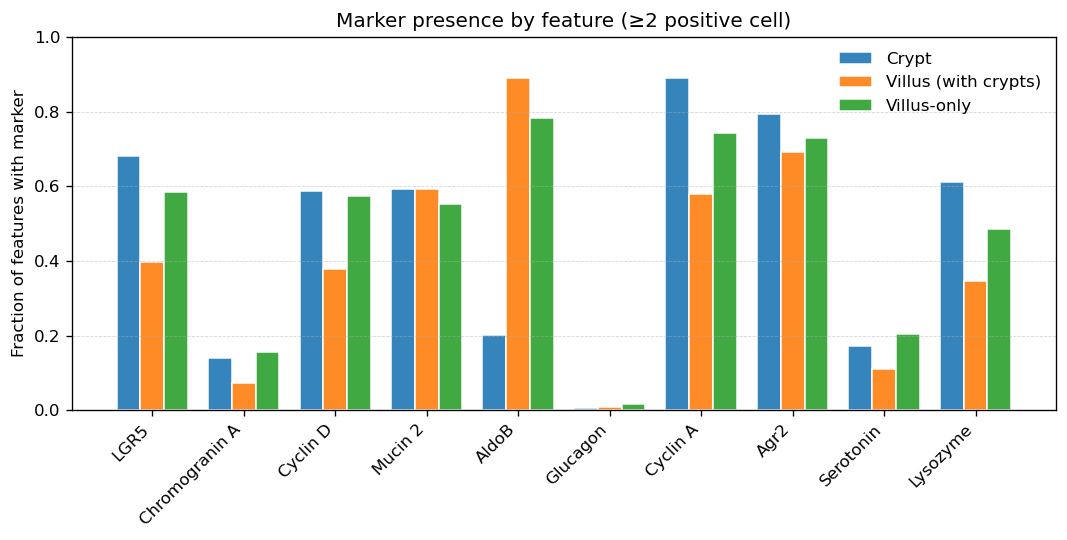

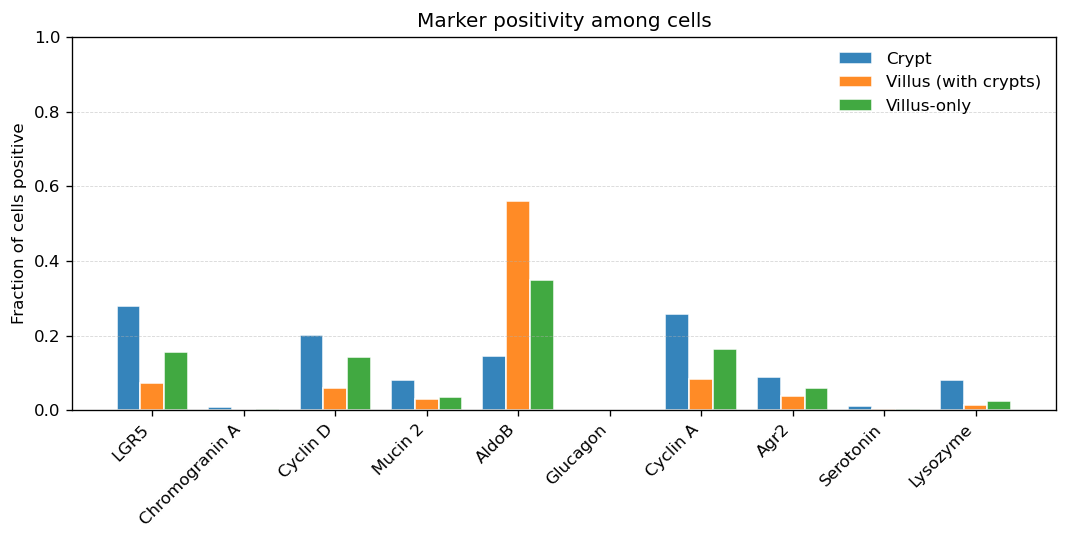

In [63]:
# --- Plotting: grouped bars with three categories ---

def _plot_grouped_bars_3(crypt_vals, villus_with_vals, villus_only_vals, ylabel, title):
    m = len(marker_names)
    x = np.arange(m)
    w = 0.26

    plt.figure(figsize=(max(9, 0.5*m), 4.6), dpi=120)
    plt.bar(x - w,      crypt_vals,        width=w, label="Crypt",               edgecolor="white", alpha=0.9)
    plt.bar(x,          villus_with_vals,  width=w, label="Villus (with crypts)",edgecolor="white", alpha=0.9)
    plt.bar(x + w,      villus_only_vals,  width=w, label="Villus-only",         edgecolor="white", alpha=0.9)
    plt.xticks(x, marker_names, rotation=45, ha="right")
    plt.ylim(0, 1)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.5)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

# Figure 1
_plot_grouped_bars_3(
    np.sum(marker_pos_crypt, axis=0)/np.sum(num_crypts),
    np.sum(marker_pos_villus, axis=0)/np.sum(num_villus),
    np.sum(marker_pos_single, axis=0)/np.sum(num_single),
    ylabel="Fraction of features with marker",
    title=f"Marker presence by feature (≥{min_positive} positive cell)"
)

# Figure 2
_plot_grouped_bars_3(
    np.sum(num_pos_cells_crypt, axis=0)/np.sum(num_cells_crypt),
    np.sum(num_pos_cells_villus, axis=0)/np.sum(num_cells_villus),
    np.sum(num_pos_cells_single, axis=0)/np.sum(num_cells_single),
    ylabel="Fraction of cells positive",
    title="Marker positivity among cells"
)


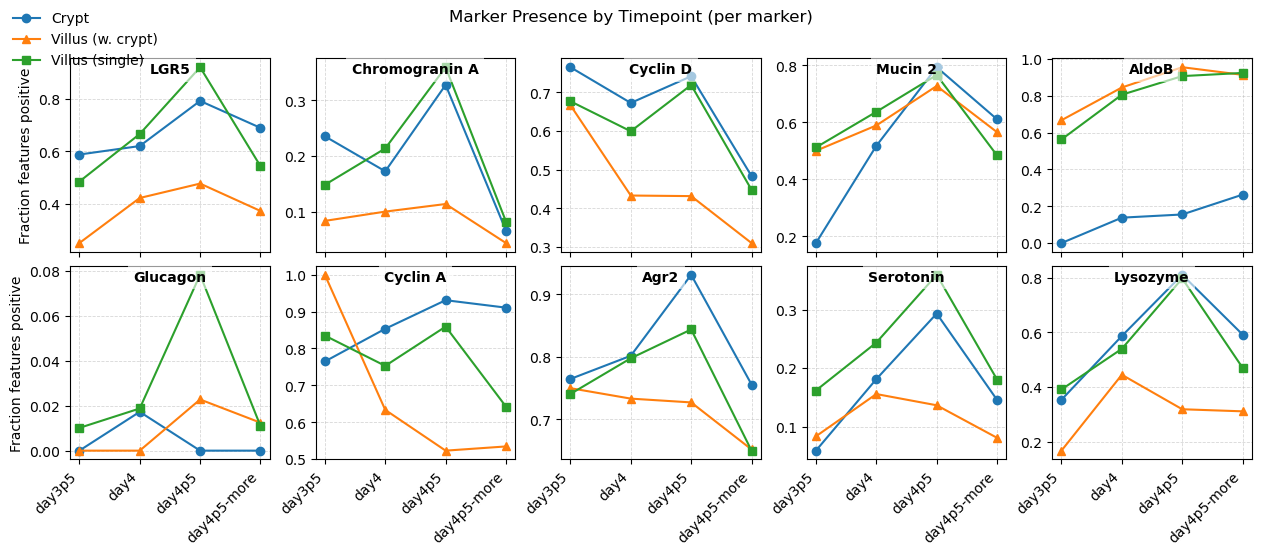

In [64]:
x = np.arange(len(timepoints))
M = len(marker_names)
n_cols = 5
n_rows = int(np.ceil(M / n_cols))

fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(2.5 * n_cols, 2.5 * n_rows),
        sharex=True, sharey=False,
        constrained_layout=True
    )

for i in range(M):
    r, c = divmod(i, n_cols)
    ax = axes[r, c]

    ax.plot(x, marker_pos_crypt[:,i]/num_crypts, marker='o', label='Crypt')
    ax.plot(x, marker_pos_villus[:,i]/num_villus, marker='^', label='Villus (w. crypt)')
    ax.plot(x, marker_pos_single[:,i]/num_single, marker='s', label='Villus (single)')

    ax.text(
        0.5, 0.98,                       # near the top-center of the axes
        marker_names[i],
        transform=ax.transAxes,
        ha="center", va="top",
        fontweight="bold", fontsize=10,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.6)  # optional halo for readability
    )
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)

    # x ticks = timepoints (rotate for readability)
    ax.set_xticks(x)
    ax.set_xticklabels(timepoints, rotation=45, ha="right")

    # y-label only on leftmost column
    if c == 0:
        ax.set_ylabel("Fraction features positive")

    # Single, figure-level legend
    # (grab handles/labels from the first visible axis)
    for rr in range(n_rows):
        for cc in range(n_cols):
            if axes[rr, cc].get_visible():
                handles, labels = axes[rr, cc].get_legend_handles_labels()
                break
        else:
            continue
        break


fig.legend(handles, labels, loc="upper left", ncol=1, frameon=False)
fig.suptitle("Marker Presence by Timepoint (per marker)", y=1.08, fontsize=12)
plt.show()

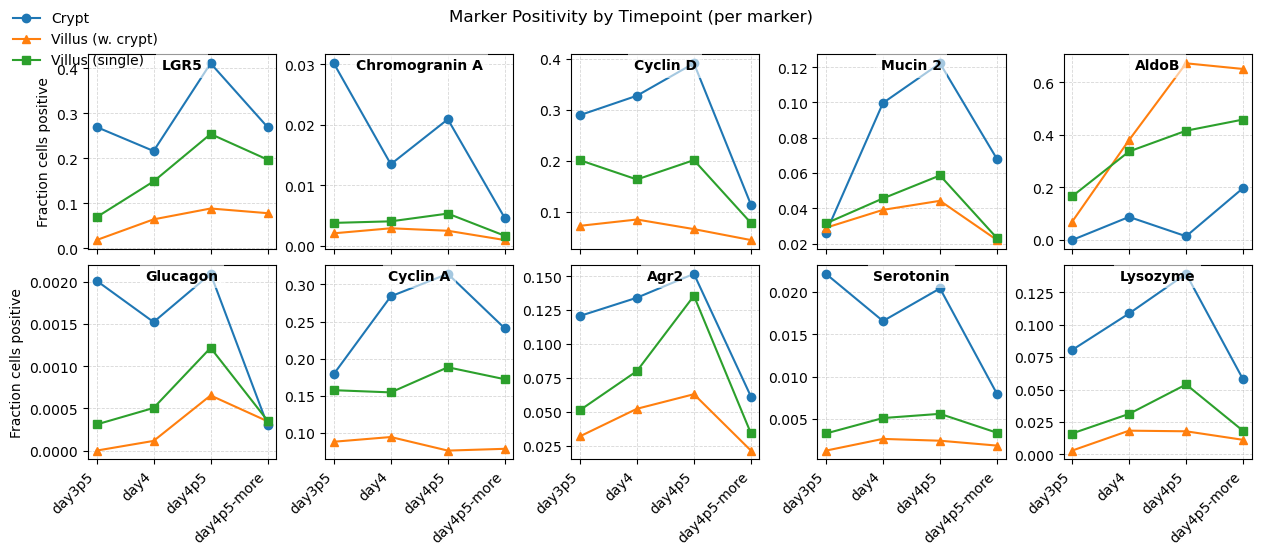

In [65]:
x = np.arange(len(timepoints))
M = len(marker_names)
n_cols = 5
n_rows = int(np.ceil(M / n_cols))

fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(2.5 * n_cols, 2.5 * n_rows),
        sharex=True, sharey=False,
        constrained_layout=True
    )

for i in range(M):
    r, c = divmod(i, n_cols)
    ax = axes[r, c]

    ax.plot(x, num_pos_cells_crypt[:,i]/num_cells_crypt, marker='o', label='Crypt')
    ax.plot(x, num_pos_cells_villus[:,i]/num_cells_villus, marker='^', label='Villus (w. crypt)')
    ax.plot(x, num_pos_cells_single[:,i]/num_cells_single, marker='s', label='Villus (single)')

    ax.text(
        0.5, 0.98,                       # near the top-center of the axes
        marker_names[i],
        transform=ax.transAxes,
        ha="center", va="top",
        fontweight="bold", fontsize=10,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.6)  # optional halo for readability
    )
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)

    # x ticks = timepoints (rotate for readability)
    ax.set_xticks(x)
    ax.set_xticklabels(timepoints, rotation=45, ha="right")

    # y-label only on leftmost column
    if c == 0:
        ax.set_ylabel("Fraction cells positive")

    # Single, figure-level legend
    # (grab handles/labels from the first visible axis)
    for rr in range(n_rows):
        for cc in range(n_cols):
            if axes[rr, cc].get_visible():
                handles, labels = axes[rr, cc].get_legend_handles_labels()
                break
        else:
            continue
        break


fig.legend(handles, labels, loc="upper left", ncol=1, frameon=False)
fig.suptitle("Marker Positivity by Timepoint (per marker)", y=1.08, fontsize=12)
plt.show()

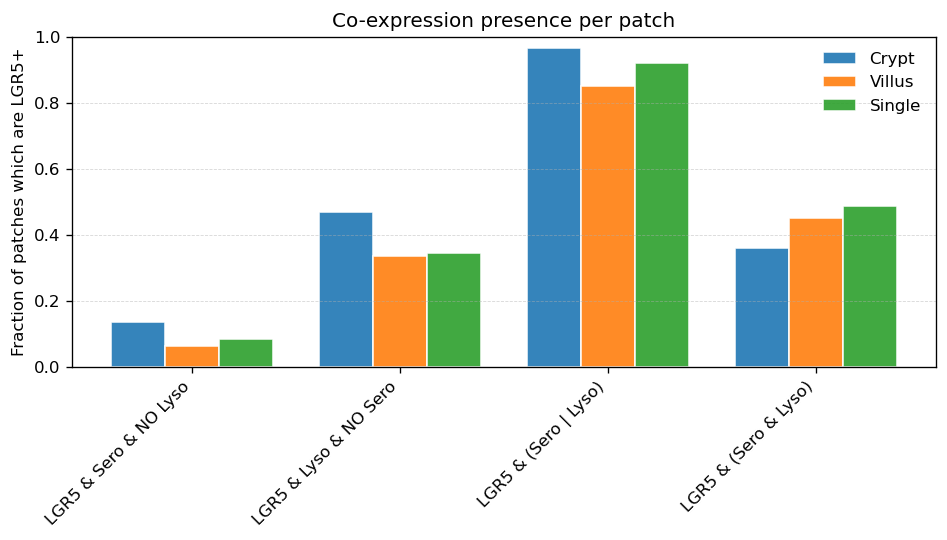

In [66]:
# --- Fractions per condition ---
labels_cond = [
    "LGR5 & Sero & NO Lyso",
    "LGR5 & Lyso & NO Sero",
    "LGR5 & (Sero | Lyso)",
    "LGR5 & (Sero & Lyso)",
]


# --- Plot grouped bars (crypt vs villus) ---
x = np.arange(len(labels_cond))
w = 0.26

plt.figure(figsize=(max(8, 0.6*len(labels_cond)), 4.6), dpi=120)
plt.bar(x - w, np.sum(coexpression_crypt, axis=0)/np.sum(marker_pos_crypt[:,i_LGR5], axis=0),  width=w, label="Crypt",  edgecolor="white", alpha=0.9)
plt.bar(x , np.sum(coexpression_villus, axis=0)/np.sum(marker_pos_villus[:,i_LGR5], axis=0), width=w, label="Villus", edgecolor="white", alpha=0.9)
plt.bar(x + w, np.sum(coexpression_single, axis=0)/np.sum(marker_pos_single[:,i_LGR5], axis=0), width=w, label="Single", edgecolor="white", alpha=0.9)
plt.xticks(x, labels_cond, rotation=45, ha="right")
plt.ylim(0, 1)
plt.ylabel("Fraction of patches which are LGR5+")
plt.title("Co-expression presence per patch")
plt.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.5)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

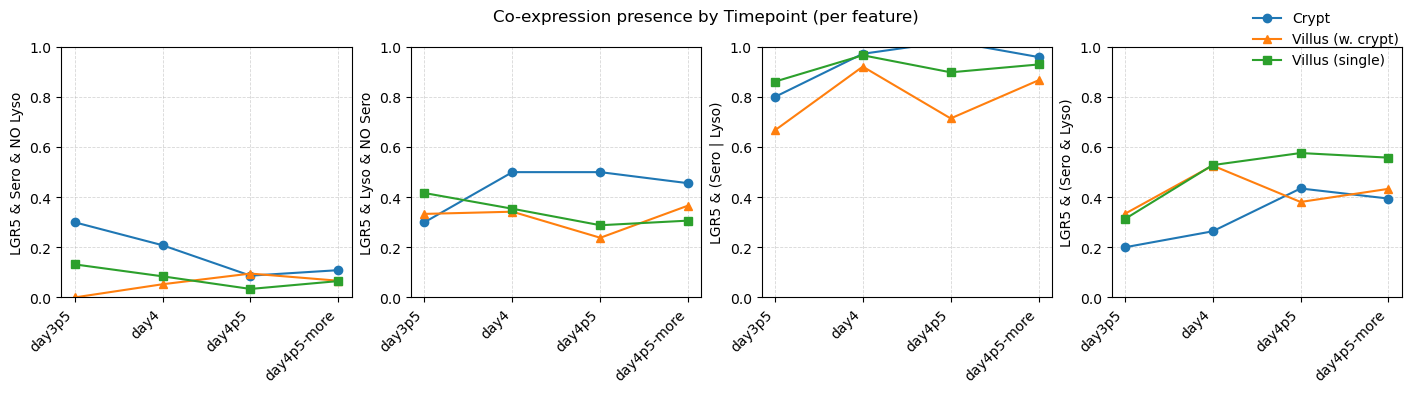

In [67]:
x = np.arange(len(timepoints))
n_cols = 4
n_rows = int(np.ceil(len(labels_cond) / n_cols))

fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(3.5 * n_cols, 3.5 * n_rows),
        sharex=True, sharey=False,
        constrained_layout=True
    )

for i in range(len(labels_cond)):

    ax = axes[i]

    ax.plot(x, coexpression_crypt[:,i]/marker_pos_crypt[:,i_LGR5], marker='o', label='Crypt')
    ax.plot(x, coexpression_villus[:,i]/marker_pos_villus[:,i_LGR5], marker='^', label='Villus (w. crypt)')
    ax.plot(x, coexpression_single[:,i]/marker_pos_single[:,i_LGR5], marker='s', label='Villus (single)')

    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)

    # x ticks = timepoints (rotate for readability)
    ax.set_xticks(x)
    ax.set_xticklabels(timepoints, rotation=45, ha="right")
    ax.set_ylabel(labels_cond[i])
    ax.set_ylim([0, 1])

    # Single, figure-level legend
    # (grab handles/labels from the first visible axis)

    handles, labels = axes[i].get_legend_handles_labels()


fig.legend(handles, labels, loc="upper right", ncol=1, frameon=False)
fig.suptitle("Co-expression presence by Timepoint (per feature)", y=1.08, fontsize=12)
plt.show()

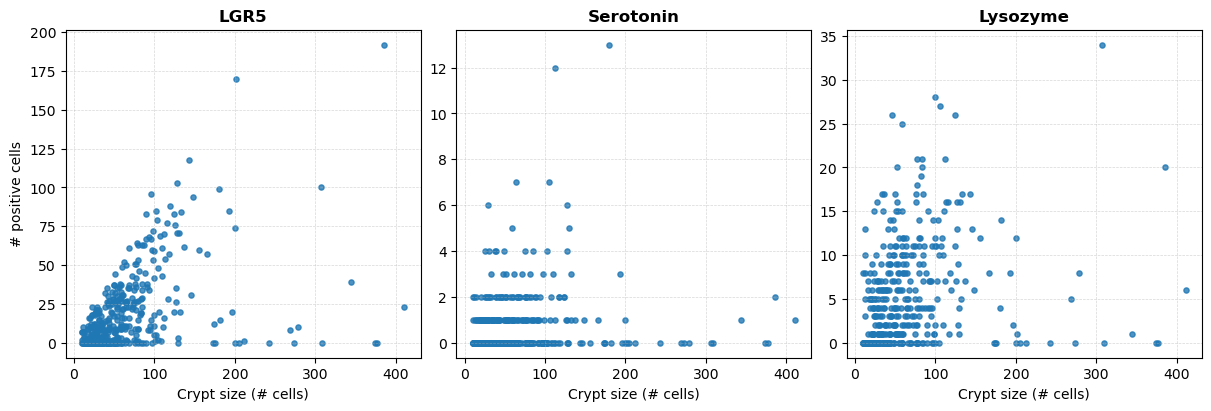

In [68]:
def get_marker_counts_per_patch(patch, markers):
    idx = np.fromiter(patch, dtype=np.int64)
    num_pos_cells = np.sum(markers[idx, :], axis=0).astype(np.int64)
    num_cells = len(idx)
    return num_pos_cells, num_cells

def split_villus_by_organoid(villus_patches, crypt_patches):
    """Return (villus_only, villus_with_crypts) as two lists of sets."""
    if crypt_patches and len(crypt_patches) > 0:
        return [], list(villus_patches)
    else:
        return list(villus_patches), []

# --- configuration ---
min_cells = 10  # e.g. 5 to require at least 5 cells per region (patch)
min_positive = 2

# --- aggregate across all timepoints/organoids ---
num_pos_cells_crypt_all = []
num_cells_crypt_all = []

for tp, d in results.items(): # loop over timepoints
    markers_all  = d.get("markers_all",  np.array([], dtype=object))
    crypts_all   = d.get("crypts_all",   [])
    villus_all   = d.get("villus_all",   [])
    marker_names = d.get("marker_names", None)

    if markers_all.size == 0:
        continue

    if isinstance(crypts_all, np.ndarray): crypts_all = crypts_all.tolist()

    n_items = len(markers_all)
    for i in range(n_items): # loop over organoids in timepoint
        markers = markers_all[i]  # (n_cells, n_markers)
        if markers is None:
            continue

        crypt_patches = _to_patch_list(crypts_all[i] if i < len(crypts_all) else None)

        # (OPTIONAL) filter out regions with too few cells
        crypt_patches  = [p for p in crypt_patches  if len(p) >= min_cells]

        for patch in crypt_patches:
            num_pos_cells, num_cells = get_marker_counts_per_patch(patch, markers)
            
            num_cells_crypt_all.append(num_cells)
            num_pos_cells_crypt_all.append(num_pos_cells)


# Stack to (n_crypts, n_markers)
pos_mat = np.vstack([np.asarray(v, dtype=int) for v in num_pos_cells_crypt_all])  # each v is a vector per crypt
sizes   = np.asarray(num_cells_crypt_all, dtype=int)                               # (n_crypts,)

markers = [("LGR5", i_LGR5), ("Serotonin", i_Sero), ("Lysozyme", i_Lyso)]

fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True, sharex=True, sharey=False)

for ax, (name, idx) in zip(axes, markers):
    y = pos_mat[:, idx]
    ax.scatter(sizes, y, s=14, alpha=0.8)
    # y = x reference line
    ax.set_title(name, fontweight="bold")
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)

axes[0].set_ylabel("# positive cells")
for ax in axes:
    ax.set_xlabel("Crypt size (# cells)")

plt.show()


## Spatially resolved marker composition in crypts

In [69]:
def _crypt_bottom_index(HKS, t_HKS, crypt_nodes):
    """Pick node in crypt with max mean HKS across selected time indices."""
    idx = np.fromiter(crypt_nodes, dtype=int)
    z = HKS[idx,:]*t_HKS                   
    agg = np.nanmean(z, axis=1)                  # simple, robust aggregate
    return int(idx[np.nanargmax(agg)])

def _neck_nodes_for_crypt(G, crypt_nodes, neck_patches):
    """
    Return all neck nodes from neck_patches that touch this crypt:
      - overlap with crypt nodes, or
      - are 1-hop neighbors of any crypt node.
    """

    # collect neighbors of crypt (1-hop shell)
    crypt_neighbors = set()
    for u in crypt_nodes:
        crypt_neighbors.update(G.neighbors(u))

    touching = set()
    for neck in neck_patches:
        # include neck nodes that overlap with crypt (defensive) or touch via an edge
        if (neck & crypt_nodes) or (neck & crypt_neighbors):
            touching |= neck

    return touching


# def _normalized_distance_to_bottom(geo, bottom_idx, neck_nodes):
#     """
#     geo: (N,N) geodesic matrix for this organoid
#     bottom_idx: int (bottom cell)
#     neck_nodes: set of ints (ring candidates)
#     Return: distance to bottom cell in units of crypt length.
#     """

#     neck_idx = np.fromiter(neck_nodes, dtype=int)
#     crypt_length = np.mean(geo[bottom_idx, neck_idx]) # for now, take the mean
#     dist_to_bottom = geo[bottom_idx, :]/crypt_length
#     return dist_to_bottom


def _normalized_distance_to_bottom(geo, bottom_idx, neck_nodes):
    """
    geo: (N,N) geodesic matrix for this organoid
    bottom_idx: int (bottom cell)
    neck_nodes: set of ints (ring candidates)
    Return: distance to bottom cell in units of crypt length.
    """

    neck_idx = np.fromiter(neck_nodes, dtype=int)
    closest_neck = np.argmin( geo[neck_idx, :], axis=0) # index closest neck node
    dist_bottom = geo[bottom_idx, :] # distance to crypt bottom

    # "crypt length" varies, if neck is on the side of the crypt.
    # Define crypt length wrt. closest neck cell
    crypt_length = dist_bottom[closest_neck]

    return dist_bottom/crypt_length


def _bin_marker_positivity(markers, dnorm, bin_edges):
    """
    Bin marker positivity across the ENTIRE organoid by normalized distance.

    Parameters
    ----------
    markers : (N, M) array-like (bool/int)
        Per-cell marker matrix (True/1 = positive). N cells, M markers.
    dnorm : (N,) array-like (float)
        Normalized distance for each cell (e.g., distance from bottom / distance to nearest neck).
        Can include values >1 if you want neck/villus in the same histogram.
    bin_edges : (K+1,) array-like (float)
        Bin edges for np.digitize (e.g., np.linspace(0, 1.0, 11)).

    Returns
    -------
    counts_pos  : (M, K) float array  (number of positive cells per marker in each bin)
    counts_total: (K,) int array      (number of cells in each bin)
    """

    if markers.ndim != 2:
        raise ValueError("markers must be a 2D array (N, M).")
    if dnorm.ndim != 1 or dnorm.shape[0] != markers.shape[0]:
        raise ValueError("dnorm must be 1D with length N (same N as markers).")

    N, M = markers.shape
    nb = len(bin_edges) - 1

    # Assign bins (0..nb-1)
    bin_ids = np.digitize(dnorm, bin_edges) - 1

    counts_pos = np.zeros((M, nb), dtype=np.int64)
    counts_total = np.zeros(nb, dtype=np.int64)

    # Loop bins; ignore out-of-range ids (<0 or >=nb)
    for b in range(nb):
        mask = (bin_ids == b)
        if not np.any(mask):
            continue


        counts_total[b] = np.sum(mask)
        block = markers[mask, :].astype(bool)   
        counts_pos[:, b] = np.sum(block, axis=0)   

    return counts_pos, counts_total


# =========================
# MAIN ANALYSIS LOOP (aggregated across organoids)
# =========================

# Config
bin_edges = np.linspace(0.0, 1.4, 20)      # normalized distance bins (0..1)
bin_centers = 0.5 * (np.asarray(bin_edges[:-1]) + np.asarray(bin_edges[1:]))

# Accumulate numerators/denominators per bin across crypts to get a robust curve
M = len(marker_names)
num_pos_per_bin = np.zeros((len(timepoints), M, len(bin_centers)))  # shape (M, nbins)
num_cells_per_bin = np.zeros((len(timepoints), len(bin_centers)))     # shape (nbins,)

j = -1

for tp, d in results.items():
    HKS_all       = d.get("HKS_all",       np.array([], dtype=object))
    crypts_all    = d.get("crypts_all",    [])
    necks_all     = d.get("necks_all",     None)  # optional
    markers_all   = d.get("markers_all",   np.array([], dtype=object))
    geodesic_all  = d.get("dist_heat_all",  np.array([], dtype=object))  # (N,N) per organoid
    Gs            = d.get("cell_graphs_all", [])

    j += 1

    if isinstance(crypts_all, np.ndarray): crypts_all = crypts_all.tolist()
    if isinstance(necks_all, np.ndarray): necks_all = necks_all.tolist()

    n_items = len(HKS_all)
    for i in range(n_items): # loop over organoids
        HKS = HKS_all[i]
        markers = markers_all[i]
        geo = geodesic_all[i]
        G = Gs[i]

        crypt_patches = _to_patch_list(crypts_all[i] if i < len(crypts_all) else None)
        neck_patches = _to_patch_list(necks_all[i] if i < len(necks_all) else None)

        if not crypt_patches:
            continue

        # process each crypt separately and aggregate
        for crypt in crypt_patches:

            # 1) bottom of crypt
            bottom = _crypt_bottom_index(HKS, t_HKS, crypt)

            # 2) neck ring for this crypt
            neck_nodes = _neck_nodes_for_crypt(G, crypt, neck_patches)
            if len(neck_nodes) == 0: continue

            # 3) normalized distance (bottom -> neck is 1)
            dist_norm = _normalized_distance_to_bottom(geo, bottom, neck_nodes)

            # 4) bin marker positivity across normalized distance
            counts_pos, counts_total = _bin_marker_positivity(markers, dist_norm, bin_edges)

            # accumulate weighted by counts
            num_pos_per_bin[j] += counts_pos
            num_cells_per_bin[j] += counts_total




/tmp/ipykernel_6964/593726990.py:59: RuntimeWarning:

divide by zero encountered in divide

/tmp/ipykernel_6964/593726990.py:59: RuntimeWarning:

invalid value encountered in divide



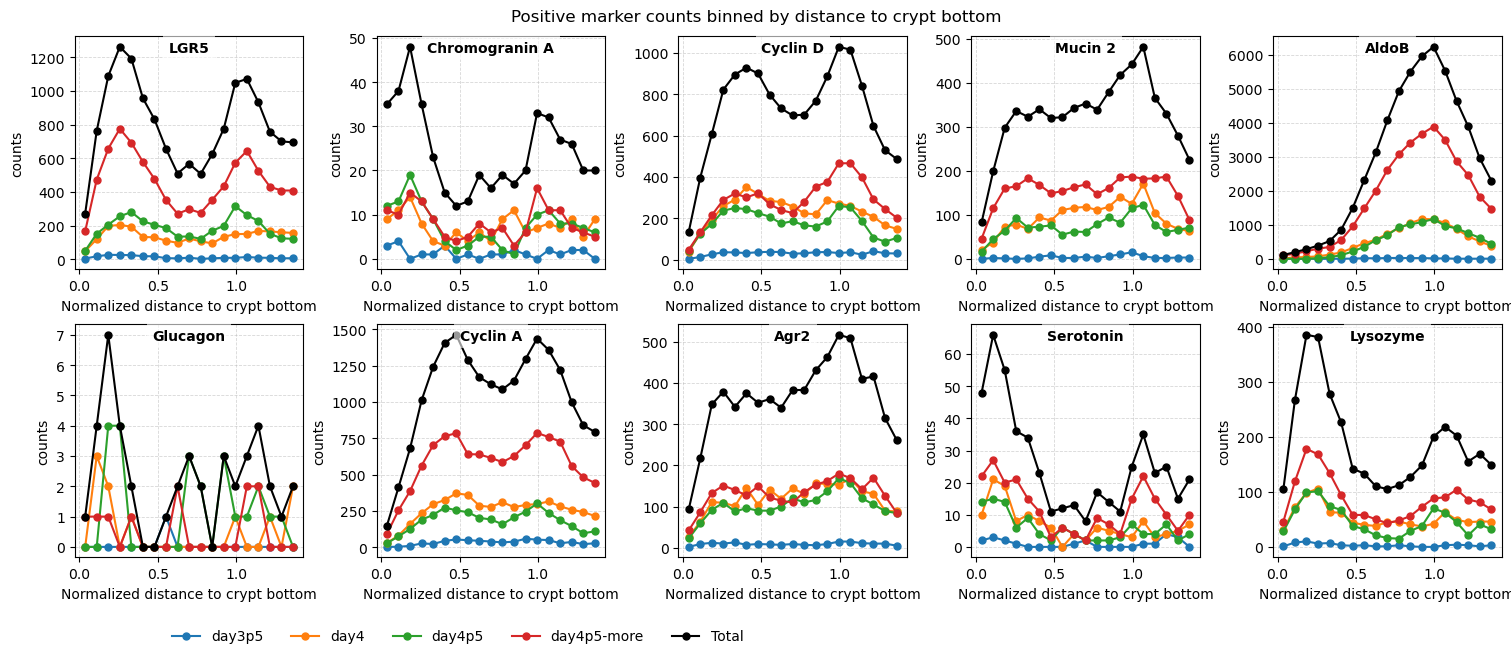

In [70]:
M = len(marker_names)
n_cols = 5
n_rows = int(np.ceil(M / n_cols))

fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(3 * n_cols, 3 * n_rows),
        sharex=False, sharey=False,
        constrained_layout=True
    )

for i in range(M):
    r, c = divmod(i, n_cols)
    ax = axes[r, c]

    ax.plot(bin_centers, num_pos_per_bin[:,i,:].T, marker='o', linewidth=1.5, markersize=5)
    ax.plot(bin_centers, np.sum(num_pos_per_bin[:,i,:], axis=0), marker='o', linewidth=1.5, markersize=5, color='k', label='Combined')

    ax.text(
        0.5, 0.98,                       # near the top-center of the axes
        marker_names[i],
        transform=ax.transAxes,
        ha="center", va="top",
        fontweight="bold", fontsize=10,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.6)  # optional halo for readability
    )
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
    ax.set_xlabel("Normalized distance to crypt bottom")
    ax.set_ylabel("counts")

# build legend labels: all timepoints + total
legend_labels = timepoints + ['Total']

# use handles from the first subplot
handles = [axes.flat[0].lines[j] for j in range(len(timepoints) + 1)]

# place legend below all subplots
fig.legend(handles, legend_labels,
           loc='upper right',
           ncol=min(6, len(legend_labels)),
           bbox_to_anchor=(0.5, -0.02),
           frameon=False)


plt.suptitle("Positive marker counts binned by distance to crypt bottom")
plt.show()


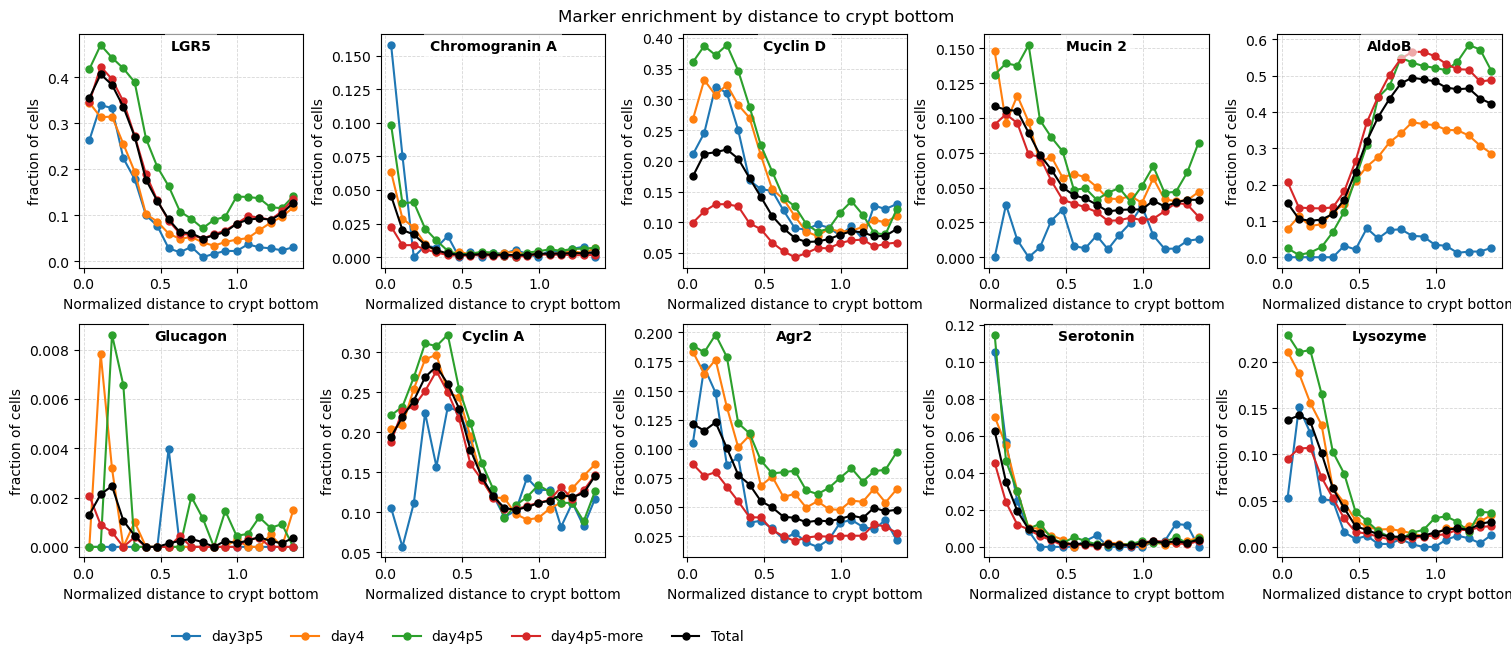

In [ ]:
M = len(marker_names)
n_cols = 5
n_rows = int(np.ceil(M / n_cols))

fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(3 * n_cols, 3 * n_rows),
        sharex=False, sharey=False,
        constrained_layout=True
    )

for i in range(M):
    r, c = divmod(i, n_cols)
    ax = axes[r, c]

    ax.plot(bin_centers, num_pos_per_bin[:,i,:].T/num_cells_per_bin.T, linewidth=1.5, markersize=5)
    ax.plot(bin_centers, np.sum(num_pos_per_bin[:,i,:], axis=0)/np.sum(num_cells_per_bin, axis=0), marker='o', linewidth=1.5, markersize=5, color='k', label='Combined')

    ax.text(
        0.5, 0.98,                       # near the top-center of the axes
        marker_names[i],
        transform=ax.transAxes,
        ha="center", va="top",
        fontweight="bold", fontsize=10,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.6)  # optional halo for readability
    )
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
    ax.set_xlabel("Normalized distance to crypt bottom")
    ax.set_ylabel("fraction of cells")

# build legend labels: all timepoints + total
legend_labels = timepoints + ['Total']

# use handles from the first subplot
handles = [axes.flat[0].lines[j] for j in range(len(timepoints) + 1)]

# place legend below all subplots
fig.legend(handles, legend_labels,
           loc='upper right',
           ncol=min(6, len(legend_labels)),
           bbox_to_anchor=(0.5, -0.02),
           frameon=False)


plt.suptitle("Marker enrichment by distance to crypt bottom")
plt.show()


## Curvature correlations in the crypts

(404, 24, 1, 1)


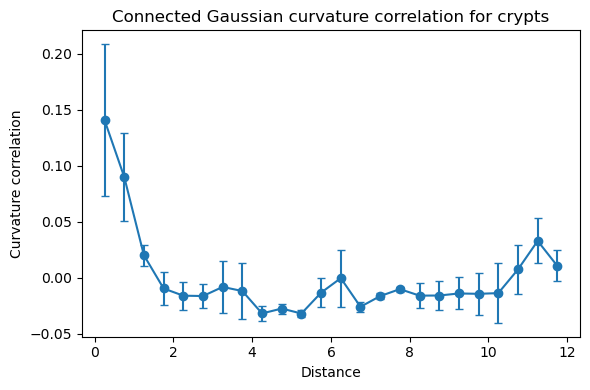

In [72]:
from src.nonlocal_correlations import *

dmax = 12
nbins = 24
bin_edges = np.linspace(0.0, dmax, nbins + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])


def hks_to_curv_proxy_single_t(hks_col, t, d=2):
    """
    Convert a single HKS column (N,) at diffusion time t to a curvature-like target:
      Y_t = (6/t) * [ (4πt)^{d/2} * HKS_t - 1 ]  ~  Gaussian curvature
    Returns float32 (N,).
    """
    h = np.asarray(hks_col, dtype=np.float64).reshape(-1)
    t = float(t)
    Y = (6.0 / t) * ((4.0 * np.pi * t) ** (d / 2.0) * h - 1.0)
    return Y.astype(np.float32)


curv_corr_conn = []
num_cells_crypts = []

for tp, d in results.items():
    dist_heat_all= d.get("dist_heat_all",  np.array([], dtype=object))
    HKS_all      = d.get("HKS_all",  np.array([], dtype=object))
    crypts_all   = d.get("crypts_all",   [])

    if isinstance(crypts_all, np.ndarray): crypts_all = crypts_all.tolist()

    n_orgs = len(markers_all)
    for i in range(n_orgs):
        crypt_patches = _to_patch_list(crypts_all[i] if i < len(crypts_all) else None)


        if len(crypt_patches) == 0:
            continue

        for patch in crypt_patches:
            idx = np.fromiter(patch, dtype=int)
            
            dist_heat_crypt = dist_heat_all[i][np.ix_(idx, idx)]
            areas_dummy = np.zeros(len(idx))
            curv_crypt = hks_to_curv_proxy_single_t(HKS_all[i][idx, 0], 1.0)

            bins_dist = pair_bins_by_distance(dist_heat_crypt, areas_dummy, bin_edges, use_area_weights=False)
            Corr, Corr_conn, _, _ = compute_two_point_correlations(bins_dist, curv_crypt)
            
            curv_corr_conn.append(Corr_conn)
            num_cells_crypts.append(len(idx))


curv_corr_conn = np.stack(curv_corr_conn)
print(curv_corr_conn.shape)


# Plot the curvature correlations of the crypts
A = curv_corr_conn[:, :, 0, 0]             # shape: (n_reps, n_bins)

means = np.nanmean(A, axis=0)
std   = np.nanstd(A, axis=0, ddof=1)       # sample std (use ddof=0 for population)
n     = np.sum(~np.isnan(A), axis=0)

# avoid meaningless error bars where n < 2
std = np.where(n > 1, std, np.nan)
sem = np.where(n > 1, std / np.sqrt(n), np.nan)

plt.figure(figsize=(6, 4))
plt.errorbar(bin_centers, means, yerr=sem, fmt='o-', capsize=3)
plt.xlabel("Distance")
plt.ylabel("Curvature correlation")
plt.title("Connected Gaussian curvature correlation for crypts")
# plt.legend()
plt.tight_layout()


/tmp/ipykernel_6964/3645180646.py:15: RuntimeWarning:

Mean of empty slice

/home/fmoller/miniforge3/envs/SphericalHarmonics/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning:

Degrees of freedom <= 0 for slice.



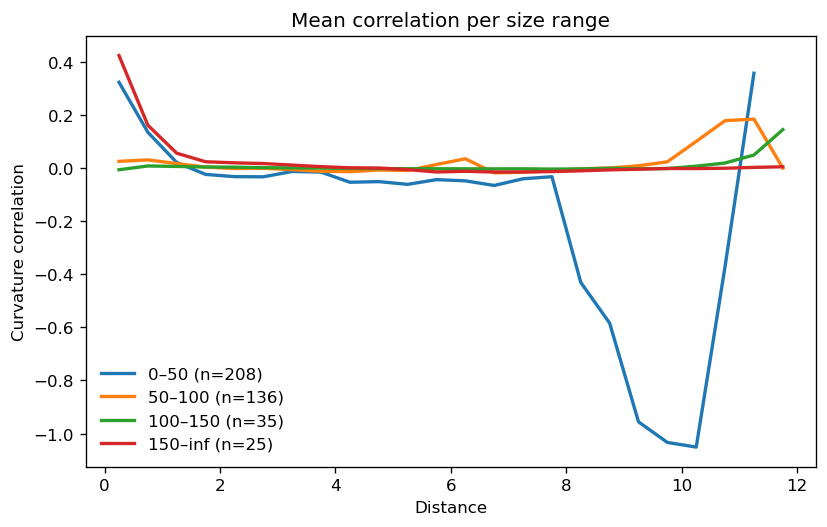

In [73]:
A = np.asarray(curv_corr_conn[:, :, 0, 0], dtype=float)  # (n_curves, n_bins)
num_cells_crypts = np.asarray(num_cells_crypts)

# Define your size bins (edges are inclusive on the right except the first)
bin_edges = np.array([0, 50, 100, 150, np.inf])  # <-- set your own ranges
bin_ids = np.digitize(num_cells_crypts, bin_edges, right=True)  # 1..len(bin_edges)

plt.figure(figsize=(7, 4.5), dpi=120)

for b in range(1, len(bin_edges)):
    mask = (bin_ids == b)
    n = np.sum(mask)
    if n == 0:
        continue
    mean_curve = np.nanmean(A[mask], axis=0)
    # optional: shaded variability
    std_curve  = np.nanstd(A[mask], axis=0, ddof=1) if n > 1 else np.full(A.shape[1], np.nan)

    lo = bin_edges[b-1]
    hi = bin_edges[b]
    label = f"{lo:g}–{hi:g} (n={n})"

    plt.plot(bin_centers, mean_curve, linewidth=2, label=label)
    # plt.fill_between(bin_centers, mean_curve-std_curve, mean_curve+std_curve, alpha=0.15)

plt.xlabel("Distance")
plt.ylabel("Curvature correlation")
plt.title("Mean correlation per size range")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

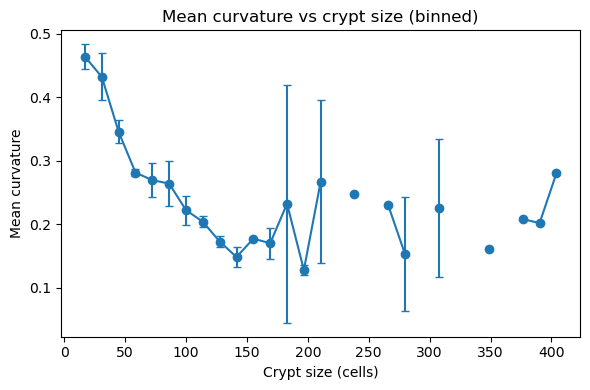

In [74]:
mean_curv_per_crypt = []
num_cells_crypts = []   # keep as you already do

for tp, d in results.items():
    dist_heat_all = d.get("dist_heat_all", np.array([], dtype=object))
    HKS_all       = d.get("HKS_all",       np.array([], dtype=object))
    crypts_all    = d.get("crypts_all",    [])
    if isinstance(crypts_all, np.ndarray): crypts_all = crypts_all.tolist()

    n_orgs = len(HKS_all)  # or whatever list matches your indices here
    for i in range(n_orgs):
        crypt_patches = _to_patch_list(crypts_all[i] if i < len(crypts_all) else None)
        if not crypt_patches: 
            continue

        for patch in crypt_patches:
            idx = np.fromiter(patch, dtype=int)

            # per-crypt curvature values (one per cell)
            curv_crypt = hks_to_curv_proxy_single_t(HKS_all[i][idx, 0], 1.0)

            # store one number per crypt: its mean curvature (ignore NaNs)
            mean_curv_per_crypt.append(np.nanmean(curv_crypt))
            num_cells_crypts.append(len(idx))

# choose edges you like; here: automatic binning
sizes = np.asarray(num_cells_crypts)
vals  = np.asarray(mean_curv_per_crypt)

edges = np.histogram_bin_edges(sizes, bins='auto')
bin_ids = np.digitize(sizes, edges, right=True)

bin_centers = 0.5*(edges[:-1] + edges[1:])
means = np.full(len(bin_centers), np.nan)
sems  = np.full(len(bin_centers), np.nan)

for b in range(1, len(edges)):
    m = (bin_ids == b)
    v = vals[m]
    n = np.sum(~np.isnan(v))
    if n == 0: 
        continue
    mu = np.nanmean(v)
    sd = np.nanstd(v, ddof=1) if n > 1 else np.nan
    se = sd/np.sqrt(n) if n > 1 else np.nan
    means[b-1] = mu
    sems[b-1]  = se

plt.figure(figsize=(6,4))
plt.errorbar(bin_centers, means, yerr=sems, fmt='o-', capsize=3)
plt.xlabel("Crypt size (cells)")
plt.ylabel("Mean curvature")
plt.title("Mean curvature vs crypt size (binned)")
plt.tight_layout()



## Crypt imbalances (in organoids with 2+ crypts)

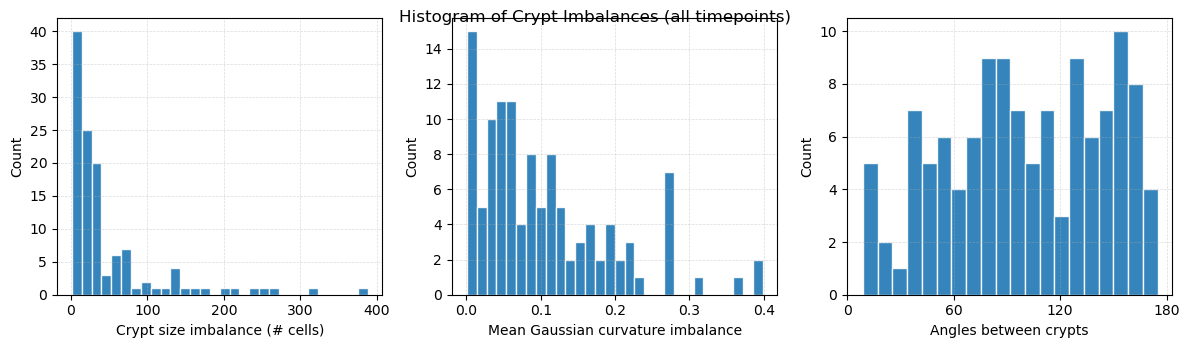

In [75]:

def hks_to_curv_proxy_single_t(hks_col, t, d=2):
    """
    Convert a single HKS column (N,) at diffusion time t to a curvature-like target:
      Y_t = (6/t) * [ (4πt)^{d/2} * HKS_t - 1 ]  ~  Gaussian curvature
    Returns float32 (N,).
    """
    h = np.asarray(hks_col, dtype=np.float64).reshape(-1)
    t = float(t)
    Y = (6.0 / t) * ((4.0 * np.pi * t) ** (d / 2.0) * h - 1.0)
    return Y.astype(np.float32)


size_diff = []
curv_diff = []
angles_deg = []  # NEW: pairwise angles between crypts (in degrees)

for tp, d in results.items():
    HKS_all        = d.get("HKS_all",        np.array([], dtype=object))
    crypts_all     = d.get("crypts_all",     [])
    villus_all     = d.get("villus_all",     [])
    centroids_all  = d.get("centroids_all",  np.array([], dtype=object))

    # normalize potentially object arrays/lists
    if isinstance(crypts_all, np.ndarray): crypts_all = crypts_all.tolist()
    if isinstance(villus_all, np.ndarray): villus_all = villus_all.tolist()

    n_orgs = len(HKS_all)
    for i in range(n_orgs):
        crypt_patches = _to_patch_list(crypts_all[i] if i < len(crypts_all) else None)
        villus_patches = _to_patch_list(villus_all[i] if i < len(villus_all) else None)
        if not villus_patches:
            continue  # need a villus to define the rays
        villus_patch = villus_patches[0]  # you filtered to exactly one villus earlier

        # only examine organoids with 2 or more crypts
        num_crypts = len(crypt_patches)
        if num_crypts < 2:
            continue

        # --- size/curvature diffs (as before) ---
        crypt_sizes = np.zeros(num_crypts, dtype=float)
        crypt_mean_curv = np.zeros(num_crypts, dtype=float)

        for j, patch in enumerate(crypt_patches):
            idx = np.fromiter(patch, dtype=int)
            curv_crypt = hks_to_curv_proxy_single_t(HKS_all[i][idx, 0], 1.0)
            crypt_sizes[j] = len(idx)
            crypt_mean_curv[j] = np.nanmean(curv_crypt)

        diff = crypt_sizes[:, None] - crypt_sizes[None, :]
        size_diff.append(diff[np.triu_indices(num_crypts, k=1)])

        diff = crypt_mean_curv[:, None] - crypt_mean_curv[None, :]
        curv_diff.append(diff[np.triu_indices(num_crypts, k=1)])

        # --- ANGLES: villus→crypt rays ---
        C = centroids_all[i]  # shape (n_cells, 3) or (n_cells, d)
        if C is None:
            continue

        # villus center-of-mass
        v_idx = np.fromiter(villus_patch, dtype=int)
        v_com = np.nanmean(C[v_idx, :], axis=0)

        # crypt centers & rays
        rays = []
        for patch in crypt_patches:
            idx = np.fromiter(patch, dtype=int)
            c_com = np.nanmean(C[idx, :], axis=0)
            ray = c_com - v_com
            rays.append(ray)

        rays = np.asarray(rays, dtype=float)  # (num_crypts, d)
        # normalize norms (avoid zero by masking)
        norms = np.linalg.norm(rays, axis=1)
        valid = norms > 0
        if np.count_nonzero(valid) < 2:
            continue  # cannot form angles

        # pairwise angles via dot product
        # Build full cosine matrix: cos(theta_ij) = (ri·rj) / (||ri||*||rj||)
        R = rays.copy()
        # Safe normalization
        Rn = np.zeros_like(R)
        Rn[valid] = R[valid] / norms[valid, None]

        cosM = np.clip(Rn @ Rn.T, -1.0, 1.0)  # (num_crypts, num_crypts)
        theta = np.degrees(np.arccos(cosM))   # angles in degrees
        # keep strictly upper triangle (i<j)
        angles_deg.append(theta[np.triu_indices(num_crypts, k=1)])



size_diff = np.abs(np.concatenate(size_diff))
curv_diff = np.abs(np.concatenate(curv_diff))
angles_deg = np.concatenate(angles_deg)

plt.figure(figsize=(12, 3.5))

plt.subplot(1, 3, 1)
plt.hist(size_diff, bins=30, edgecolor="white", alpha=0.9)
plt.xlabel("Crypt size imbalance (# cells)")
plt.ylabel("Count")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.45)
plt.tight_layout()

plt.subplot(1, 3, 2)
lo, hi = np.percentile(curv_diff, [0, 95])
plt.hist(curv_diff, bins=30, range=(lo, hi), edgecolor="white", alpha=0.9)
plt.xlabel("Mean Gaussian curvature imbalance")
plt.ylabel("Count")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.45)
plt.tight_layout()

plt.subplot(1, 3, 3)
plt.hist(angles_deg, bins=20, edgecolor="white", alpha=0.9)
plt.xticks([0, 60, 120, 180])
plt.xlabel("Angles between crypts")
plt.ylabel("Count")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.45)
plt.tight_layout()

plt.suptitle("Histogram of Crypt Imbalances (all timepoints)")
plt.show()
